# Week 11 Notebook 2: Vision-Language Models, OCR, and Prompting with Images

This notebook supports the **Vision and Multimodal Intelligence** part of the lecture.

## What this notebook covers
- Vision-language model (VLM) style workflows
- OCR and text extraction from images
- Prompting with images
- Comparing vague vs specific prompts
- Turning image inputs into usable structured outputs

## Lecture sections
- Section 5: Vision-Language Models (VLMs)
- Section 6: OCR and Structured Text Extraction
- Section 7: Prompting with Images

## The flow:
1. Show a simple document-like image.
2. Extract text from the image with OCR.
3. Ask different prompts over the same extracted content.
4. Show how prompt specificity changes output quality.
5. Connect OCR and prompting back into multimodal pipelines.

## 0. Setup

This notebook uses:
- **PIL** for image generation / loading
- **matplotlib** for display
- **pytesseract** for OCR (if available)
- simple prompt templates for demonstrating multimodal reasoning

If OCR is unavailable in your environment, the notebook will still run and fall back to a manually supplied transcript.


In [1]:
# Uncomment if needed
# !pip install pillow matplotlib pytesseract

from pathlib import Path
import textwrap
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt

print("Notebook 2 setup complete.")


Notebook 2 setup complete.


## 1. Create a Demo Receipt / Document Image

To keep this lecture self-contained, we generate a synthetic receipt-like image in code.
This avoids relying on web access or external files during class.


In [2]:
demo_dir = Path("demo_images")
demo_dir.mkdir(exist_ok=True)

receipt_path = demo_dir / "demo_receipt.png"

width, height = 900, 650
img = Image.new("RGB", (width, height), "white")
draw = ImageDraw.Draw(img)

try:
    font = ImageFont.truetype("DejaVuSans.ttf", 28)
    font_bold = ImageFont.truetype("DejaVuSans-Bold.ttf", 34)
except:
    font = ImageFont.load_default()
    font_bold = ImageFont.load_default()

lines = [
    ("Campus Market", font_bold),
    ("123 Green St, Urbana, IL", font),
    ("----------------------------------------", font),
    ("Milk                1 x $3.49", font),
    ("Bread               1 x $2.99", font),
    ("Eggs                1 x $4.29", font),
    ("Bananas             2 x $0.79", font),
    ("----------------------------------------", font),
    ("Subtotal                $12.35", font),
    ("Tax                      $1.05", font),
    ("Total                   $13.40", font_bold),
    ("Date: 04/01/2026", font),
]

y = 40
for text, fnt in lines:
    draw.text((50, y), text, fill="black", font=fnt)
    y += 48

img.save(receipt_path)
receipt_path


PosixPath('demo_images/demo_receipt.png')

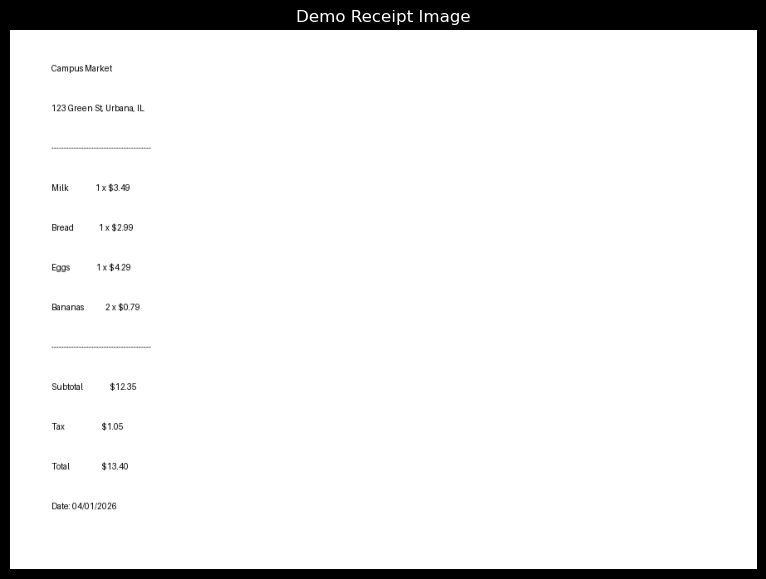

In [3]:
plt.figure(figsize=(10, 7))
plt.imshow(Image.open(receipt_path))
plt.title("Demo Receipt Image")
plt.axis("off")
plt.show()


## 2. Section 6 Demo OCR: Extracting Text from the Image

OCR answers the question:

> **What text is visible in the image?**

It does **not** fully answer:
- what the image means
- what should be done with the information
- how the result should be summarized

That is where prompting and downstream reasoning come in.


In [4]:
# You might need to install tesseract using:
# brew install tesseract


ocr_available = True
ocr_text = None

try:
    import pytesseract
    ocr_text = pytesseract.image_to_string(Image.open(receipt_path))
except Exception as e:
    ocr_available = False
    print("OCR engine not available in this environment.")
    print("Reason:", e)

if not ocr_available:
    ocr_text = '''
Campus Market
123 Green St, Urbana, IL

Milk                1 x $3.49
Bread               1 x $2.99
Eggs                1 x $4.29
Bananas             2 x $0.79

Subtotal                $12.35
Tax                      $1.05
Total                   $13.40
Date: 04/01/2026
'''.strip()

print("OCR text extracted:\n")
print(ocr_text)


OCR text extracted:

Campus Market

128Green St Urbana, IL

Milk 1383.49

Bread 1x$299

Eggs 1x$429

Bananas 2x 80.79

Subtotal $12.95
Tax $105
Tol $13.40

Date: 04/01/2028



### Notes
OCR gives us raw text, but raw text is not yet a product feature.
We still need:
- interpretation
- formatting
- summarization
- validation


## 3. Section 5 Demo: Simulating a Vision-Language Workflow

In a real VLM:
- image + prompt -> model -> text answer

Here, we demonstrate the same logic by using:
- the image
- OCR output as visible evidence
- prompt templates that simulate downstream reasoning tasks

This will now demonstrate:
- task grounding
- output differences
- prompt sensitivity


## 4. Section 7 Demo: Prompting with Images

We now ask different prompts about the **same receipt image**.

The visible evidence remains the same.
Only the task instruction changes.


In [5]:
def prompt_vague(extracted_text: str) -> str:
    return f"""You are given OCR text extracted from an image.

OCR TEXT:
{extracted_text}

Task:
Describe what this image likely represents and what type of document it is.

Keep it high-level."""

def prompt_summary(extracted_text: str) -> str:
    return f"""You are given OCR text from a receipt.

OCR TEXT:
{extracted_text}

Task:
Write a concise summary in 2 sentences.

Requirements:
- Include merchant name
- Include total amount
- Mention key items if possible
- Do not repeat raw text

Output only the summary."""

def prompt_structured(extracted_text: str) -> str:
    return f"""You are given OCR text from a receipt.

OCR TEXT:
{extracted_text}

Task:
Extract the fields strictly in valid JSON format.

Schema:
{{
  "merchant": string,
  "items": [{{"name": string, "quantity": number, "price": number}}],
  "subtotal": number,
  "tax": number,
  "total": number,
  "date": string
}}

Rules:
- Do not include explanations
- Do not add extra text
- If a field is missing, use null

Return ONLY valid JSON."""

vague_prompt = prompt_vague(ocr_text)
summary_prompt = prompt_summary(ocr_text)
structured_prompt = prompt_structured(ocr_text)

print("Vague prompt:\n")
print(vague_prompt[:700])


Vague prompt:

You are given OCR text extracted from an image.

OCR TEXT:
Campus Market

128Green St Urbana, IL

Milk 1383.49

Bread 1x$299

Eggs 1x$429

Bananas 2x 80.79

Subtotal $12.95
Tax $105
Tol $13.40

Date: 04/01/2028


Task:
Describe what this image likely represents and what type of document it is.

Keep it high-level.


In [6]:
print("Summary prompt:\n")
print(summary_prompt[:700])

print("\n" + "="*80 + "\n")

print("Structured prompt:\n")
print(structured_prompt[:900])


Summary prompt:

You are given OCR text from a receipt.

OCR TEXT:
Campus Market

128Green St Urbana, IL

Milk 1383.49

Bread 1x$299

Eggs 1x$429

Bananas 2x 80.79

Subtotal $12.95
Tax $105
Tol $13.40

Date: 04/01/2028


Task:
Write a concise summary in 2 sentences.

Requirements:
- Include merchant name
- Include total amount
- Mention key items if possible
- Do not repeat raw text

Output only the summary.


Structured prompt:

You are given OCR text from a receipt.

OCR TEXT:
Campus Market

128Green St Urbana, IL

Milk 1383.49

Bread 1x$299

Eggs 1x$429

Bananas 2x 80.79

Subtotal $12.95
Tax $105
Tol $13.40

Date: 04/01/2028


Task:
Extract the fields strictly in valid JSON format.

Schema:
{
  "merchant": string,
  "items": [{"name": string, "quantity": number, "price": number}],
  "subtotal": number,
  "tax": number,
  "total": number,
  "date": string
}

Rules:
- Do not include explanations
- Do not add extra text
- If a field is missing, use null

Return ONLY valid JSON.


## 5. The Difference Between Weak and Strong Prompts

Below, we simulate the kind of outputs we would expect from a multimodal model.
Here, you can replace this part with a live VLM call whenever you'll practice at home.


In [7]:
# Note: INFO 490 students: Uncomment the code underneath and insert your own model.

# from transformers import pipeline
#
# generator = pipeline(
#     "text-generation",
#     model="YOUR_MODEL_NAME",   # replace with your chosen model
#     max_new_tokens=300,
#     do_sample=False
# )
#
# def run_model(prompt: str) -> str:
#     result = generator(prompt)[0]["generated_text"]
#     # remove the original prompt if the model echoes it
#     if result.startswith(prompt):
#         result = result[len(prompt):].strip()
#     return result.strip()
#
# real_vague_output = run_model(vague_prompt)
# real_summary_output = run_model(summary_prompt)
# real_structured_output = run_model(structured_prompt)
#
# print("VAGUE OUTPUT:\\n")
# print(real_vague_output)
#
# print("\\n" + "="*80 + "\\n")
# print("SUMMARY OUTPUT:\\n")
# print(real_summary_output)
#
# print("\\n" + "="*80 + "\\n")
# print("STRUCTURED OUTPUT:\\n")
# print(real_structured_output)

In [8]:
# Note: I'm printing a plain text string to show how your text generation model should return the results when passed the queries in previous cell.

simulated_vague_output = '''
This image appears to show a store receipt or purchase record. It contains a store name, itemized purchases, pricing information, and a total amount paid.
'''.strip()

simulated_summary_output = '''
This is a receipt from Campus Market at 123 Green St, Urbana, IL. The purchase includes milk, bread, eggs, and bananas. The subtotal is $12.35, tax is $1.05, and the final total is $13.40.
'''.strip()

simulated_structured_output = '''
{
  "merchant": "Campus Market",
  "items": [
    {"name": "Milk", "price": 3.49, "quantity": 1},
    {"name": "Bread", "price": 2.99, "quantity": 1},
    {"name": "Eggs", "price": 4.29, "quantity": 1},
    {"name": "Bananas", "price": 0.79, "quantity": 2}
  ],
  "subtotal": 12.35,
  "tax": 1.05,
  "total": 13.40,
  "date": "04/01/2026"
}
'''.strip()

print("VAGUE OUTPUT:\n")
print(simulated_vague_output)

print("\n" + "="*80 + "\n")
print("SUMMARY OUTPUT:\n")
print(simulated_summary_output)

print("\n" + "="*80 + "\n")
print("STRUCTURED OUTPUT:\n")
print(simulated_structured_output)


VAGUE OUTPUT:

This image appears to show a store receipt or purchase record. It contains a store name, itemized purchases, pricing information, and a total amount paid.


SUMMARY OUTPUT:

This is a receipt from Campus Market at 123 Green St, Urbana, IL. The purchase includes milk, bread, eggs, and bananas. The subtotal is $12.35, tax is $1.05, and the final total is $13.40.


STRUCTURED OUTPUT:

{
  "merchant": "Campus Market",
  "items": [
    {"name": "Milk", "price": 3.49, "quantity": 1},
    {"name": "Bread", "price": 2.99, "quantity": 1},
    {"name": "Eggs", "price": 4.29, "quantity": 1},
    {"name": "Bananas", "price": 0.79, "quantity": 2}
  ],
  "subtotal": 12.35,
  "tax": 1.05,
  "total": 13.40,
  "date": "04/01/2026"
}


### Thus,
Same image.
Same evidence.
Different prompts.
Different outputs.

This is the control layer of multimodal systems.


## 6. OCR vs Interpretation

A strong lecture moment is to contrast:
- raw OCR text
- human-readable summary
- structured extraction

These are **different system tasks**.

OCR alone is not the final product.


In [9]:
# Note: INFO 490 students: This is how sample output should look like
wrapped_ocr = textwrap.fill(ocr_text.replace("\n", " "), width=90)

print("RAW OCR TEXT:\n")
print(wrapped_ocr)

print("\n" + "="*90 + "\n")
print("INTERPRETED SUMMARY:\n")
print(textwrap.fill(simulated_summary_output, width=90))

print("\n" + "="*90 + "\n")
print("STRUCTURED EXTRACTION:\n")
print(simulated_structured_output)


RAW OCR TEXT:

Campus Market  128Green St Urbana, IL  Milk 1383.49  Bread 1x$299  Eggs 1x$429  Bananas 2x
80.79  Subtotal $12.95 Tax $105 Tol $13.40  Date: 04/01/2028


INTERPRETED SUMMARY:

This is a receipt from Campus Market at 123 Green St, Urbana, IL. The purchase includes
milk, bread, eggs, and bananas. The subtotal is $12.35, tax is $1.05, and the final total
is $13.40.


STRUCTURED EXTRACTION:

{
  "merchant": "Campus Market",
  "items": [
    {"name": "Milk", "price": 3.49, "quantity": 1},
    {"name": "Bread", "price": 2.99, "quantity": 1},
    {"name": "Eggs", "price": 4.29, "quantity": 1},
    {"name": "Bananas", "price": 0.79, "quantity": 2}
  ],
  "subtotal": 12.35,
  "tax": 1.05,
  "total": 13.40,
  "date": "04/01/2026"
}


## 7. Optional: Add a Noisy OCR Scenario

Real OCR is imperfect.
This cell demonstrates why prompting and validation matter when OCR is messy.


In [10]:
# Note: INFO 490 students: Another example
noisy_ocr_text = '''
Campus Market
123 Green St, Urbana, IL

Milk                1 x $3.49
Bread               1 x $2.99
Eggs                1 x $4.29
Bananas             2 x $0.79

Subtotai                $12.35
Tax                      $1.05
TotaI                   $13.40
Date: 04/01/2026
'''.strip()

print("NOISY OCR TEXT:\n")
print(noisy_ocr_text)

print("\nSuggested teaching question:")
print("What happens if OCR mistakes 'Total' or 'Subtotal'?")


NOISY OCR TEXT:

Campus Market
123 Green St, Urbana, IL

Milk                1 x $3.49
Bread               1 x $2.99
Eggs                1 x $4.29
Bananas             2 x $0.79

Subtotai                $12.35
Tax                      $1.05
TotaI                   $13.40
Date: 04/01/2026

Suggested teaching question:
What happens if OCR mistakes 'Total' or 'Subtotal'?


### Talking point
Students should see that multimodal systems are fragile in realistic ways:
- OCR noise
- ambiguous prompts
- missing layout structure

That is why production systems often combine:
- OCR
- prompting
- rules
- validation


## 10. Summary

Notebook 2 demonstrated:

1. **OCR extracts visible text**
2. **Prompting controls the task**
3. **The same image can yield different outputs depending on the instruction**
4. **Raw extraction is not the same as understanding**

This sets up the next step:
- Notebook 3: building a full multimodal pipeline
